In [3]:
import os
print(os.getcwd())

d:\yo\programacion\proyectos practicando\gestor_datos_economicos\backend\notebooks


In [4]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()

In [5]:
# Importación de librerías y modelos.

import pandas as pd
import matplotlib.pyplot as plt

from data_engine.models import (
    SerieHistoricaDeuda,
    ComposicionDeudaMoneda,
    ComposicionDeudaAcreedor,
    ComposicionDeudaLegislacion,
)

In [6]:
# Cargamos composición de la deuda (moneda).

qs_moneda = ComposicionDeudaMoneda.objects.all().values(
    "anio", "fecha_corte", "categoria", "monto_millones", "es_corte_parcial"
)
df_moneda = pd.DataFrame(qs_moneda)
df_moneda["monto_millones"] = df_moneda["monto_millones"].astype(float)  # Decimal -> float para graficar
df_moneda.head()

,anio,fecha_corte,categoria,monto_millones,es_corte_parcial
0,2005,2005-12-31,dolares_usa,6567.5,False
1,2005,2005-12-31,uf,2652.7,False
2,2005,2005-12-31,pesos,0.0,False
3,2005,2005-12-31,unidad_cuenta_bid,57.8,False
4,2005,2005-12-31,unidad_canasta_birf,0.0,False


In [7]:
qs_acreedor = ComposicionDeudaAcreedor.objects.all().values(
    "anio", "fecha_corte", "categoria", "monto_millones", "es_corte_parcial"
)
df_acreedor = pd.DataFrame(qs_acreedor)
df_acreedor["monto_millones"] = df_acreedor["monto_millones"].astype(float)
df_acreedor.head()

,anio,fecha_corte,categoria,monto_millones,es_corte_parcial
0,2005,2005-12-31,banco_central_chile,2846.0,False
1,2005,2005-12-31,birf,289.0,False
2,2005,2005-12-31,bid,536.0,False
3,2005,2005-12-31,bonos,5269.0,False
4,2005,2005-12-31,eximbank_japon,0.0,False


In [8]:
# Cargamos series históricas.

qs_serie = SerieHistoricaDeuda.objects.all().values(
    "anio", "fecha_corte", "tipo_deuda", "moneda", "monto_millones", "pct_pib", "es_corte_parcial"
)
df_serie = pd.DataFrame(qs_serie)
df_serie["monto_millones"] = df_serie["monto_millones"].astype(float)
df_serie.head()

,anio,fecha_corte,tipo_deuda,moneda,monto_millones,pct_pib,es_corte_parcial
0,1991,1991-12-31,bruta,clp,4937066.0,0.373662,False
1,1991,1991-12-31,bruta,usd,13170.0,0.373662,False
2,1991,1991-12-31,neta,clp,2972446.0,0.224969,False
3,1991,1991-12-31,neta,usd,7929.0,0.224969,False
4,1992,1992-12-31,bruta,clp,5117626.0,0.307075,False


TABLAS DE INTERSECCIÓN

In [9]:
df_moneda_completo = df_moneda[df_moneda["es_corte_parcial"] == False]

pivot_moneda = df_moneda_completo.pivot_table(
    index="anio", columns="categoria", values="monto_millones", aggfunc="sum"
)
pivot_moneda = pivot_moneda.sort_index()
pivot_moneda.head()

categoria,dolares_usa,euros,marco_aleman,otras,pesos,uf,unidad_canasta_birf,unidad_cuenta_bid,yen_japones
anio,,,,,,,,,
2005,6567.5,91.2,0.0,2.000000,0.000000,2652.7,0.0,57.800000,0.1
2006,5031.0,114.0,0.0,1.900000,0.000000,2464.7,0.0,54.900000,0.0
2007,3477.3,125.1,0.0,4.700000,342.866363,3091.4,0.0,52.600000,0.0
2008,2770.8,111.7,0.0,0.967559,588.132441,3811.8,0.0,51.600000,0.0
2009,2382.0,100.0,0.0,0.870732,1541.100000,7025.4,0.0,47.226739,0.0


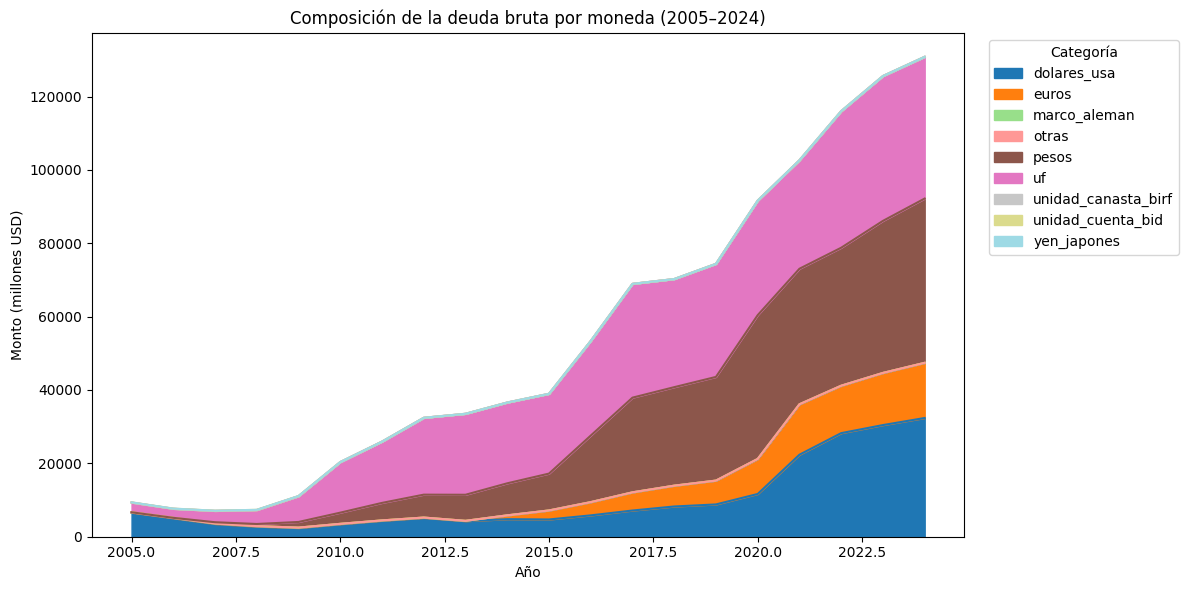

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot_moneda.plot.area(ax=ax, cmap="tab20")

ax.set_title("Composición de la deuda bruta por moneda (2005–2024)")
ax.set_xlabel("Año")
ax.set_ylabel("Monto (millones USD)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Categoría")

plt.tight_layout()
plt.show()

GRAFICO 2

In [11]:
df_acreedor_completo = df_acreedor[df_acreedor["es_corte_parcial"] == False]

pivot_acreedor = df_acreedor_completo.pivot_table(
    index="anio", columns="categoria", values="monto_millones", aggfunc="sum"
)
pivot_acreedor = pivot_acreedor.sort_index()
pivot_acreedor.head()

categoria,aid,banco_central_chile,bancoestado_chile,bid,birf,bonos,eximbank_japon,otros
anio,,,,,,,,
2005,35.0,2846.0,181.0,536.0,289.0,5269.0,0.0,214.0
2006,4.0,1268.0,165.0,550.0,346.0,5109.0,0.0,224.0
2007,2.0,139.0,181.0,551.0,354.0,5631.0,0.0,237.0
2008,0.0,0.0,137.0,591.0,200.0,6189.0,0.0,218.0
2009,0.0,0.0,153.0,632.0,215.0,9899.0,0.0,197.0


In [12]:
print(pivot_acreedor.tail(5))
print(pivot_acreedor.sum(axis=1).tail(5))

categoria  aid  banco_central_chile  bancoestado_chile          bid  \
anio                                                                  
2020       0.0                  0.0          19.360855  1279.981686   
2021       0.0                  0.0          12.305649  1956.939569   
2022       0.0                  0.0           9.000000  2290.000000   
2023       0.0                  0.0           7.000000  2654.000000   
2024       0.0                  0.0           3.822887  2865.342202   

categoria        birf          bonos  eximbank_japon       otros  
anio                                                              
2020       140.181140   90036.101078             0.0  149.510965  
2021       144.353373  100403.339517             0.0  114.966009  
2022       141.000000  113491.000000             0.0   90.000000  
2023       150.000000  122712.000000             0.0   67.000000  
2024       151.720266  127763.997109             0.0   40.288102  
anio
2020     91625.135724
2021  

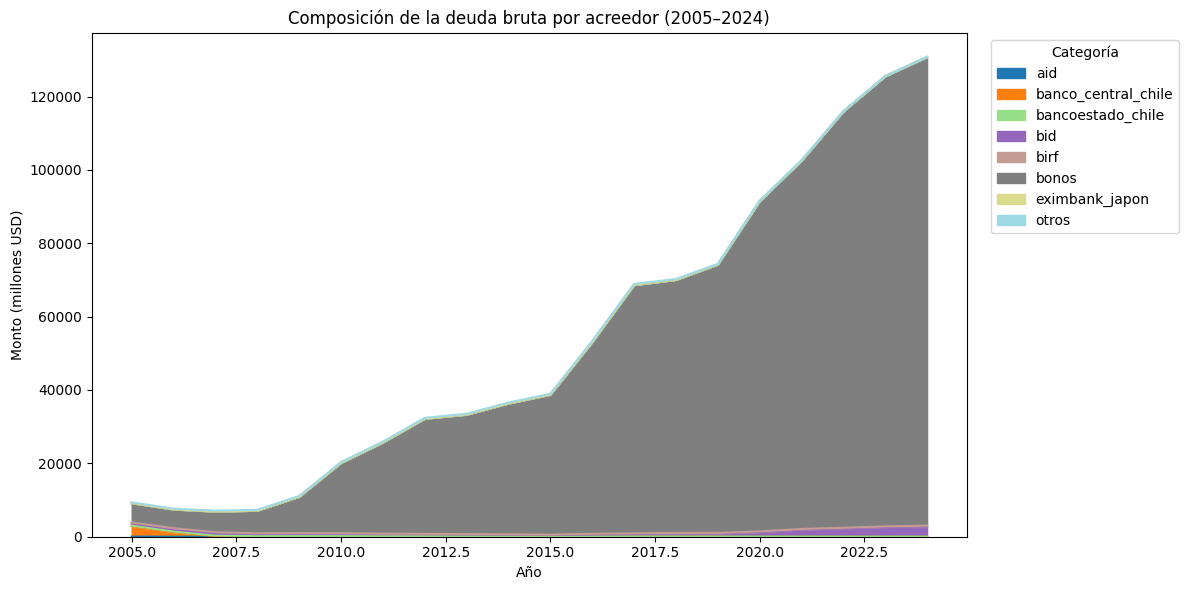

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot_acreedor.plot.area(ax=ax, cmap="tab20")

ax.set_title("Composición de la deuda bruta por acreedor (2005–2024)")
ax.set_xlabel("Año")
ax.set_ylabel("Monto (millones USD)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Categoría")

plt.tight_layout()
plt.show()

Gráficos que incluyen stock_titulo_deuda

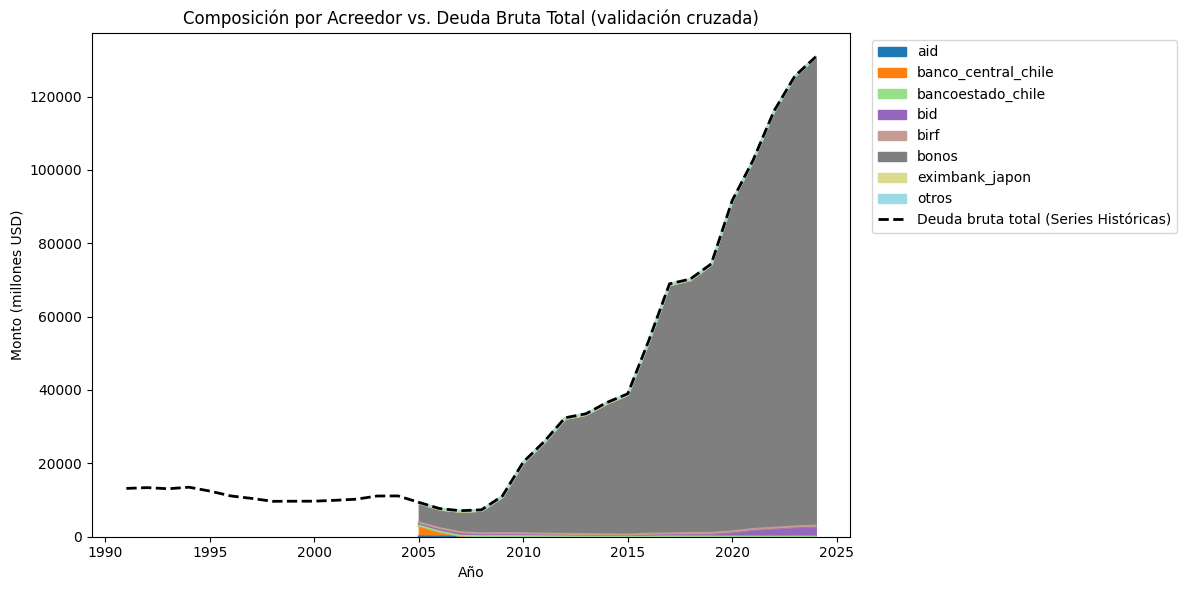

In [14]:

qs_bruta = SerieHistoricaDeuda.objects.filter(
    tipo_deuda="bruta", moneda="usd", es_corte_parcial=False
).values("anio", "monto_millones")
df_bruta = pd.DataFrame(qs_bruta).set_index("anio")["monto_millones"].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_acreedor.plot.area(ax=ax, cmap="tab20")
df_bruta.plot.line(ax=ax, color="black", linewidth=2, linestyle="--", label="Deuda bruta total (Series Históricas)")

ax.set_title("Composición por Acreedor vs. Deuda Bruta Total (validación cruzada)")
ax.set_xlabel("Año")
ax.set_ylabel("Monto (millones USD)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [15]:
comparacion = pd.DataFrame({
    "series_historicas": df_bruta,
    "composicion_suma": pivot_acreedor.sum(axis=1),
})
comparacion["diferencia"] = comparacion["series_historicas"] - comparacion["composicion_suma"]
print(comparacion.loc[2005:2012])

      series_historicas  composicion_suma  diferencia
anio                                                 
2005             9373.0            9370.0         3.0
2006             7666.0            7666.0         0.0
2007             7094.0            7095.0        -1.0
2008             7335.0            7335.0         0.0
2009            11096.0           11096.0         0.0
2010            20358.0           20358.0         0.0
2011            25928.0           25927.0         1.0
2012            32423.0           32423.0         0.0


In [16]:
qs_pct_pib = SerieHistoricaDeuda.objects.filter(
    tipo_deuda="bruta", moneda="usd", es_corte_parcial=False
).values("anio", "pct_pib")
df_pct_pib = pd.DataFrame(qs_pct_pib).set_index("anio")["pct_pib"].astype(float)
df_pct_pib.head()

anio
1991    0.373662
1992    0.307075
1993    0.282852
1994    0.227698
1995    0.173723
Name: pct_pib, dtype: float64

In [17]:
from data_engine.models.stock_titulo_deuda import StockTituloDeuda, Instrumento, Tenedor

qs_holders_anual = StockTituloDeuda.objects.tenedores_reales().fin_de_anio().filter(
    instrumento=Instrumento.BONOS_GOBIERNO_GENERAL
).values("anio", "tenedor", "monto_miles_millones_clp")

df_holders_anual = pd.DataFrame(qs_holders_anual)
df_holders_anual["monto_miles_millones_clp"] = df_holders_anual["monto_miles_millones_clp"].astype(float)

pivot_holders_anual = df_holders_anual.pivot_table(
    index="anio", columns="tenedor", values="monto_miles_millones_clp", aggfunc="sum"
)
pct_extranjeros = (pivot_holders_anual["inversionistas_extranjeros"] / pivot_holders_anual.sum(axis=1)) * 100
pct_extranjeros.head()

anio
2008    16.415724
2009     9.218554
2010    12.408499
2011    15.013547
2012    17.556328
dtype: float64

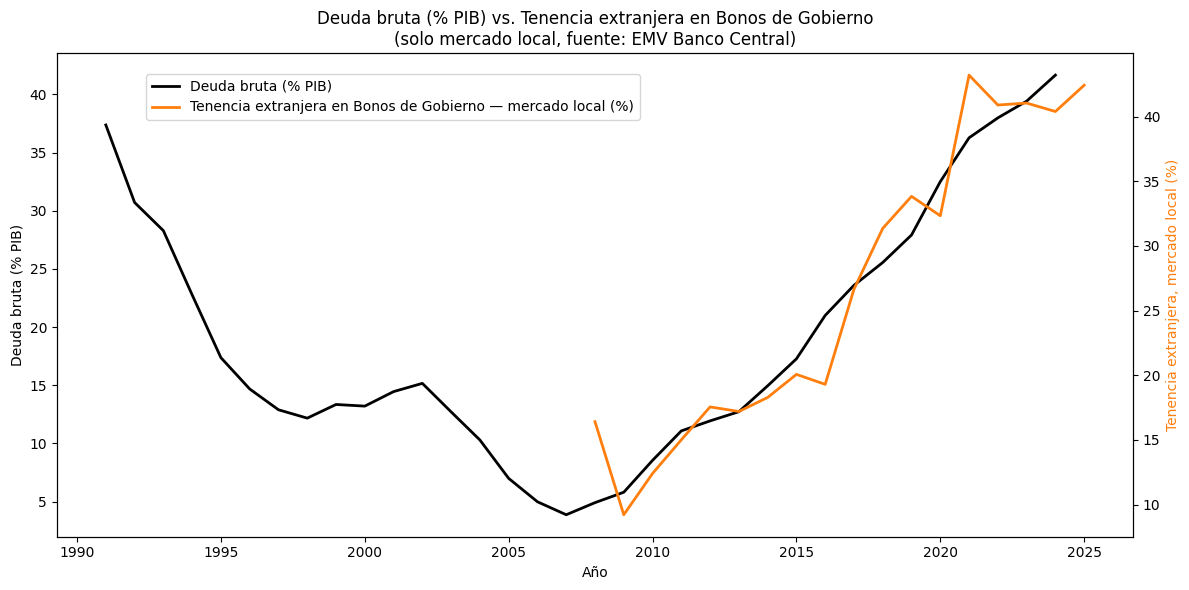

In [21]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_pct_pib.index, df_pct_pib.values * 100, color="black", linewidth=2, label="Deuda bruta (% PIB)")
ax1.set_xlabel("Año")
ax1.set_ylabel("Deuda bruta (% PIB)", color="black")

ax2 = ax1.twinx()
ax2.plot(pct_extranjeros.index, pct_extranjeros.values, color="tab:orange", linewidth=2,
          label="Tenencia extranjera en Bonos de Gobierno — mercado local (%)")
ax2.set_ylabel("Tenencia extranjera, mercado local (%)", color="tab:orange")

ax1.set_title("Deuda bruta (% PIB) vs. Tenencia extranjera en Bonos de Gobierno\n(solo mercado local, fuente: EMV Banco Central)")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()